# Milestone 1 — Dataset Acquisition and Inspection

**Project:** Intelligent Diabetic Retinopathy Detection and Progress Monitoring Using AI/ML

---

> ### ⚠️ Academic prototype — not a medical device
> This notebook is part of a student research project for **screening-support demonstration only**.
> It is not clinically validated and must not be used for diagnosis, triage, or treatment decisions.

---

## What this notebook does

1. Confirms the environment (Python, PyTorch, GPU)
2. Confirms the APTOS 2019 dataset is on disk and complete
3. Checks for duplicate IDs, missing images, and orphan files
4. Measures the class distribution and computes class weights for Milestone 5
5. Scans raw image dimensions
6. Displays sample fundus images for each severity stage
7. Saves every figure and table to `reports/` for your written report

**How to use it:** run the cells top to bottom (`Shift+Enter`). Every cell prints what it did.
Nothing here is random without a seed, so re-running gives identical results.

## Severity classes

| Label | Stage |
|------:|-------|
| 0 | No DR |
| 1 | Mild |
| 2 | Moderate |
| 3 | Severe |
| 4 | Proliferative DR |


## 1. Setup

This cell makes the project's `src/` package importable from the notebook, loads the config,
and sets the global random seed. Run it first, every time you open the notebook.

If it raises `ModuleNotFoundError: No module named 'src'`, the notebook is not inside the
project's `notebooks/` folder — check where you saved it.

In [1]:
import sys
from pathlib import Path

# The notebook lives in <project_root>/notebooks/, so the project root is one level up.
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

print("Project root :", PROJECT_ROOT)
assert (PROJECT_ROOT / "src").is_dir(), (
    f"Could not find src/ under {PROJECT_ROOT}. "
    "Make sure this notebook is saved inside the project's notebooks/ folder."
)

# Auto-reload edited src/ modules without restarting the kernel.
# This matters: you WILL edit src/data/inspect.py while working through this.
%load_ext autoreload
%autoreload 2

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src.utils.config import class_names, ensure_dirs, get_path, load_config
from src.utils.seed import set_seed

cfg = load_config()
SEED = cfg["project"]["seed"]
set_seed(SEED)

DS          = cfg["dataset"]
ID_COL      = DS["id_col"]
LABEL_COL   = DS["label_col"]
IMAGE_EXT   = DS["image_ext"]
CLASS_NAMES = class_names(cfg)

APTOS_DIR   = get_path(cfg, "aptos_dir")
TRAIN_CSV   = APTOS_DIR / DS["train_csv"]
IMAGES_DIR  = APTOS_DIR / DS["train_images"]

ensure_dirs(cfg, "reports_dir", "figures_dir")
REPORTS_DIR = get_path(cfg, "reports_dir")
FIGURES_DIR = get_path(cfg, "figures_dir")

pd.set_option("display.width", 120)
plt.rcParams["figure.dpi"] = 110

print("Seed         :", SEED)
print("Classes      :", CLASS_NAMES)
print("Dataset dir  :", APTOS_DIR)
print("Reports dir  :", REPORTS_DIR)

Project root : c:\Users\ishra\Downloads\dr_project\dr_project
Seed         : 42
Classes      : ['No DR', 'Mild', 'Moderate', 'Severe', 'Proliferative DR']
Dataset dir  : C:\Users\ishra\Downloads\dr_project\dr_project\data\raw
Reports dir  : C:\Users\ishra\Downloads\dr_project\dr_project\reports


## 2. Environment check

Confirms PyTorch can see your GPU. If `CUDA available` is `False`, training will run on CPU
and take many hours instead of ~30 minutes — worth fixing before Milestone 4.

This cell will not stop the notebook if PyTorch is missing; Milestone 1 does not need it.

In [2]:
import platform

print("Python  :", platform.python_version())
print("OS      :", platform.platform())

try:
    import torch
    print("PyTorch :", torch.__version__, "| CUDA build:", torch.version.cuda)
    if torch.cuda.is_available():
        props = torch.cuda.get_device_properties(0)
        print(f"GPU     : {props.name}  ({props.total_memory / 1e9:.1f} GB VRAM)")
        # 'available' and 'works' are not the same thing - run something real.
        _a = torch.randn(256, 256, device="cuda")
        print("GPU test: OK (matmul checksum "
              f"{(_a @ _a).sum().item():.2f})")
        del _a
        torch.cuda.empty_cache()
    else:
        print("GPU     : NOT AVAILABLE - you likely installed the CPU-only torch wheel.")
        print("          Fix: pip install torch torchvision --index-url "
              "https://download.pytorch.org/whl/cu121")
except ImportError:
    print("PyTorch : not installed yet (fine for Milestone 1, required from Milestone 4)")

Python  : 3.11.9
OS      : Windows-10-10.0.26200-SP0
PyTorch : 2.5.1+cu121 | CUDA build: 12.1
GPU     : NVIDIA GeForce RTX 3050 6GB Laptop GPU  (6.4 GB VRAM)
GPU test: OK (matmul checksum -1138.40)


## 3. Is the dataset there?

Expected layout after you unzip the Kaggle download:

```
data/raw/aptos2019/
├── train.csv
├── test.csv
├── train_images/      <- 3,662 .png files
└── test_images/
```

If this cell fails, see the "Getting the dataset" section in the README — you either
haven't unzipped it yet, or it went into a nested folder such as
`data/raw/aptos2019/aptos2019-blindness-detection/`.

In [3]:
def describe_dataset_location() -> None:
    """Print exactly what is and is not present, with a fix for each case."""
    problems = []

    if not APTOS_DIR.is_dir():
        problems.append(f"Folder missing: {APTOS_DIR}")
    else:
        print(f"Found dataset folder: {APTOS_DIR}")
        for entry in sorted(APTOS_DIR.iterdir())[:10]:
            kind = "dir " if entry.is_dir() else "file"
            size = (f"{sum(1 for _ in entry.iterdir())} files"
                    if entry.is_dir() else f"{entry.stat().st_size / 1024:.0f} KB")
            print(f"   [{kind}] {entry.name:<20} {size}")

    if not TRAIN_CSV.is_file():
        problems.append(f"Missing labels file: {TRAIN_CSV}")
    if not IMAGES_DIR.is_dir():
        problems.append(f"Missing image folder: {IMAGES_DIR}")

    if problems:
        print("\nPROBLEMS FOUND:")
        for p in problems:
            print("  -", p)
        print("\nFix: unzip the Kaggle download so that train.csv and train_images/ sit")
        print(f"     directly inside {APTOS_DIR}")
        print("     A common mistake is one extra nested folder - move the contents up a level.")
        raise FileNotFoundError("Dataset not in the expected location (see above).")

    n_images = sum(1 for _ in IMAGES_DIR.glob(f"*{IMAGE_EXT}"))
    print(f"\nOK: train.csv present, {n_images} images in {IMAGES_DIR.name}/")

describe_dataset_location()

Found dataset folder: C:\Users\ishra\Downloads\dr_project\dr_project\data\raw
   [file] .gitkeep             0 KB
   [file] train.csv            54 KB
   [dir ] train_images         3662 files

OK: train.csv present, 3662 images in train_images/


In [5]:
from src.utils.config import get_path

RAW = get_path(cfg, "raw_dir")
print("Looking under:", RAW, "\n")

if not RAW.exists():
    print("data/raw does not exist at all — nothing has been unzipped yet.")
else:
    # Show the tree, 3 levels deep
    for p in sorted(RAW.rglob("*")):
        depth = len(p.relative_to(RAW).parts)
        if depth > 3:
            continue
        if p.is_dir():
            try:
                n = sum(1 for _ in p.iterdir())
            except OSError:
                n = "?"
            print("  " * (depth - 1) + f"[dir ] {p.name}/  ({n} items)")
        elif depth <= 2:
            print("  " * (depth - 1) + f"[file] {p.name}")

# Find train.csv wherever it actually is
hits = list(RAW.rglob("train.csv"))
print("\ntrain.csv found at:", [str(h) for h in hits] or "NOWHERE")

Looking under: C:\Users\ishra\Downloads\dr_project\dr_project\data\raw 

[file] .gitkeep
[file] train.csv
[dir ] train_images/  (3662 items)
  [file] 000c1434d8d7.png
  [file] 001639a390f0.png
  [file] 0024cdab0c1e.png
  [file] 002c21358ce6.png
  [file] 005b95c28852.png
  [file] 0083ee8054ee.png
  [file] 0097f532ac9f.png
  [file] 00a8624548a9.png
  [file] 00b74780d31d.png
  [file] 00cb6555d108.png
  [file] 00cc2b75cddd.png
  [file] 00e4ddff966a.png
  [file] 00f6c1be5a33.png
  [file] 0104b032c141.png
  [file] 0124dffecf29.png
  [file] 0125fbd2e791.png
  [file] 012a242ac6ff.png
  [file] 014508ccb9cb.png
  [file] 0151781fe50b.png
  [file] 0161338f53cc.png
  [file] 0180bfa26c0b.png
  [file] 0182152c50de.png
  [file] 01b3aed3ed4c.png
  [file] 01c7808d901d.png
  [file] 01d9477b1171.png
  [file] 01eb826f6467.png
  [file] 01f7bb8be950.png
  [file] 0212dd31f623.png
  [file] 022f820027b8.png
  [file] 0231642cf1c2.png
  [file] 0232dfea7547.png
  [file] 02358b47ea89.png
  [file] 0243404e8a00.png
 

## 4. Load the labels

`load_labels()` lives in `src/data/inspect.py`. It validates that the expected columns exist
and that every label is an integer, rather than silently loading a malformed CSV.

In [4]:
from src.data.inspect import load_labels

df = load_labels(TRAIN_CSV, ID_COL, LABEL_COL)

print(f"Rows: {len(df)}")
expected = DS.get("expected_train_rows")
if expected and len(df) != expected:
    print(f"NOTE: expected {expected} rows for the public APTOS release - "
          "confirm you downloaded the right competition files.")

df.head(10)

Rows: 3662


,id_code,diagnosis
0,000c1434d8d7,2
1,001639a390f0,4
2,0024cdab0c1e,1
3,002c21358ce6,0
4,005b95c28852,0
5,0083ee8054ee,4
6,0097f532ac9f,0
7,00a8624548a9,2
8,00b74780d31d,2
9,00cb6555d108,1


## 5. Integrity checks

Three questions, and you want "no" to all three:

- Does any image ID appear twice in `train.csv`? (Duplicates would leak between train and validation.)
- Is any labelled ID missing its image file?
- Is any image file on disk absent from the CSV?

Answer these **now**. Finding a missing file during epoch 12 of training is a bad time.

In [5]:
from src.data.inspect import check_image_files, find_duplicate_ids

duplicates = find_duplicate_ids(df, ID_COL)
print(f"Duplicate IDs : {len(duplicates)}"
      + (f"  e.g. {duplicates[:5]}" if duplicates else "  (good)"))

missing, orphans = check_image_files(df, IMAGES_DIR, ID_COL, IMAGE_EXT)
print(f"Missing files : {len(missing)}"
      + (f"  e.g. {missing[:5]}" if missing else "  (good - every label has an image)"))
print(f"Orphan files  : {len(orphans)}"
      + (f"  e.g. {orphans[:5]}" if orphans else "  (good - no unlabelled images)"))

if not duplicates and not missing:
    print("\nDataset integrity: PASS")
else:
    print("\nDataset integrity: PROBLEMS - see above before continuing to Milestone 2.")

Duplicate IDs : 0  (good)
Missing files : 0  (good - every label has an image)
Orphan files  : 0  (good - no unlabelled images)

Dataset integrity: PASS


## 6. Class distribution

**This is the most important cell in the notebook.** APTOS is heavily imbalanced: roughly half
the images are class 0 (No DR), while Severe (class 3) is around 5%.

That single fact drives three later decisions:

- **Milestone 3** — the split must be *stratified*, or a random split could leave class 3 nearly
  absent from your validation set
- **Milestone 5** — weighted loss and/or oversampling, instead of plain cross-entropy
- **Milestone 6** — accuracy alone is misleading (a model predicting "No DR" for everything scores
  ~49%), so Quadratic Weighted Kappa and per-class recall are the metrics that matter

The figure this produces goes straight into your report.

In [6]:
from src.data.inspect import class_distribution

dist = class_distribution(df, LABEL_COL, DS["class_names"])
display(dist)

dist_csv = REPORTS_DIR / "m1_class_distribution.csv"
dist.to_csv(dist_csv, index=False)
print(f"Saved table -> {dist_csv.relative_to(PROJECT_ROOT)}")

,label,class_name,count,percent,ratio_to_majority
0,0,No DR,1805,49.29,1.00
1,1,Mild,370,10.10,4.88
2,2,Moderate,999,27.28,1.81
3,3,Severe,193,5.27,9.35
4,4,Proliferative DR,295,8.06,6.12


Saved table -> reports\m1_class_distribution.csv


Saved figure -> reports\figures\m1_class_distribution.png


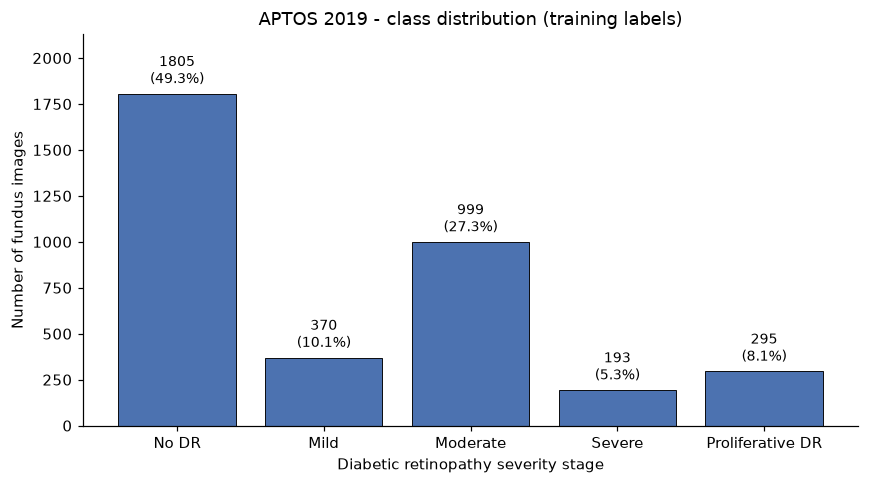

In [7]:
fig, ax = plt.subplots(figsize=(8, 4.5))
bars = ax.bar(dist["class_name"], dist["count"],
              color="#4C72B0", edgecolor="black", linewidth=0.6)

for bar, count, pct in zip(bars, dist["count"], dist["percent"]):
    ax.annotate(f"{count}\n({pct:.1f}%)",
                xy=(bar.get_x() + bar.get_width() / 2, bar.get_height()),
                xytext=(0, 4), textcoords="offset points",
                ha="center", va="bottom", fontsize=9)

ax.set_title("APTOS 2019 - class distribution (training labels)")
ax.set_xlabel("Diabetic retinopathy severity stage")
ax.set_ylabel("Number of fundus images")
ax.set_ylim(0, dist["count"].max() * 1.18)
ax.spines[["top", "right"]].set_visible(False)
fig.tight_layout()

out = FIGURES_DIR / "m1_class_distribution.png"
fig.savefig(out, dpi=150)
print(f"Saved figure -> {out.relative_to(PROJECT_ROOT)}")
plt.show()

### Class weights for Milestone 5

Inverse-frequency weights, normalised to mean 1.0. These are what you will pass to
`nn.CrossEntropyLoss(weight=...)` later.

Write the printed numbers into your report's Methodology section — deriving them from your own
data is a much better answer than "we used class weights" with no justification.

In [8]:
from src.data.inspect import suggested_class_weights

weights = suggested_class_weights(df, LABEL_COL, DS["num_classes"])

weights_df = pd.DataFrame({
    "label": range(DS["num_classes"]),
    "class_name": CLASS_NAMES,
    "count": dist["count"].values,
    "weight": weights.round(4),
})
display(weights_df)

print("For Milestone 5, paste this into your training script:")
print(f"class_weights = torch.tensor({[round(float(w), 4) for w in weights]})")

weights_df.to_csv(REPORTS_DIR / "m1_class_weights.csv", index=False)

,label,class_name,count,weight
0,0,No DR,1805,0.2159
1,1,Mild,370,1.0534
2,2,Moderate,999,0.3901
3,3,Severe,193,2.0194
4,4,Proliferative DR,295,1.3212


For Milestone 5, paste this into your training script:
class_weights = torch.tensor([0.2159, 1.0534, 0.3901, 2.0194, 1.3212])


## 7. Raw image properties

APTOS images come from several camera models at different resolutions and framing. This scan
tells you how heterogeneous they are — which is the justification for the cropping and resizing
you will implement in Milestone 2.

Scanning all ~3,662 full-resolution images takes a few minutes, so we sample 400 by default.
Set `SAMPLE_SIZE = None` for an exact scan once, for the report.

In [9]:
from src.data.inspect import scan_image_properties, summarise_image_properties

SAMPLE_SIZE = 400   # set to None to scan every image (slower, exact)

props = scan_image_properties(df[ID_COL], IMAGES_DIR, IMAGE_EXT,
                              sample_size=SAMPLE_SIZE, seed=SEED)

unreadable = props[~props["readable"]]
print(f"Scanned {len(props)} images | unreadable: {len(unreadable)}")
if len(unreadable):
    print("Unreadable IDs:", unreadable["id"].tolist()[:10])

summary = summarise_image_properties(props)
display(summary)

props.to_csv(REPORTS_DIR / "m1_image_properties.csv", index=False)
summary.to_csv(REPORTS_DIR / "m1_image_property_summary.csv")
print("Saved tables -> reports/m1_image_properties.csv, reports/m1_image_property_summary.csv")

Scanned 400 images | unreadable: 0


,width,height,aspect_ratio,mean_intensity,file_kb
count,400.00,400.00,400.00,400.00,400.00
mean,1996.40,1513.94,1.28,61.02,2288.19
std,930.11,572.71,0.19,16.39,1775.04
min,640.00,480.00,1.00,14.95,267.80
25%,1050.00,1050.00,1.00,47.92,964.25
50%,2048.00,1536.00,1.33,63.24,1854.75
75%,2588.00,1958.00,1.39,72.94,2785.45
max,4288.00,2848.00,1.51,116.69,7321.30


Saved tables -> reports/m1_image_properties.csv, reports/m1_image_property_summary.csv


Saved figure -> reports\figures\m1_image_size_scatter.png


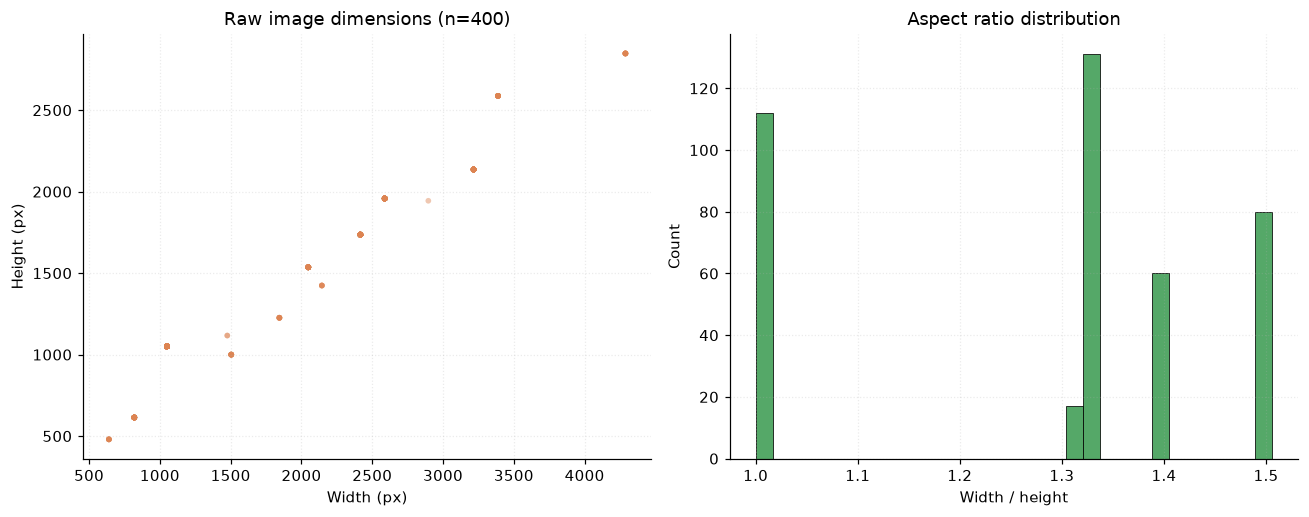


Distinct resolutions in the sample: 14
Most common:


,,count
width,height,
1050,1050,112
2416,1736,60
2588,1958,54
3216,2136,45
2048,1536,35


In [10]:
ok = props[props["readable"]]

fig, axes = plt.subplots(1, 2, figsize=(12, 4.8))

axes[0].scatter(ok["width"], ok["height"], s=14, alpha=0.45,
                color="#DD8452", edgecolors="none")
axes[0].set_title(f"Raw image dimensions (n={len(ok)})")
axes[0].set_xlabel("Width (px)")
axes[0].set_ylabel("Height (px)")
axes[0].grid(alpha=0.25, linestyle=":")

axes[1].hist(ok["aspect_ratio"], bins=30, color="#55A868", edgecolor="black", linewidth=0.5)
axes[1].set_title("Aspect ratio distribution")
axes[1].set_xlabel("Width / height")
axes[1].set_ylabel("Count")
axes[1].grid(alpha=0.25, linestyle=":")

for ax in axes:
    ax.spines[["top", "right"]].set_visible(False)

fig.tight_layout()
out = FIGURES_DIR / "m1_image_size_scatter.png"
fig.savefig(out, dpi=150)
print(f"Saved figure -> {out.relative_to(PROJECT_ROOT)}")
plt.show()

print(f"\nDistinct resolutions in the sample: {ok.groupby(['width', 'height']).ngroups}")
print("Most common:")
display(ok.groupby(["width", "height"]).size()
          .sort_values(ascending=False).head(5).rename("count").to_frame())

## 8. What the images actually look like

Look carefully at this grid before moving on. Two things to notice, because they justify
Milestone 2's preprocessing:

1. **Black borders.** Every fundus photo is a circle on a black rectangle, and the amount of
   black varies. Resizing without cropping wastes 30–50% of the input on black pixels and makes
   the effective magnification differ between images.
2. **The lesions are tiny.** Microaneurysms — the earliest sign of DR — are only a few pixels
   across at full resolution. This is why input resolution matters more than network depth here,
   and why we use 300×300 rather than 224×224.

Saved figure -> reports\figures\m1_sample_grid.png


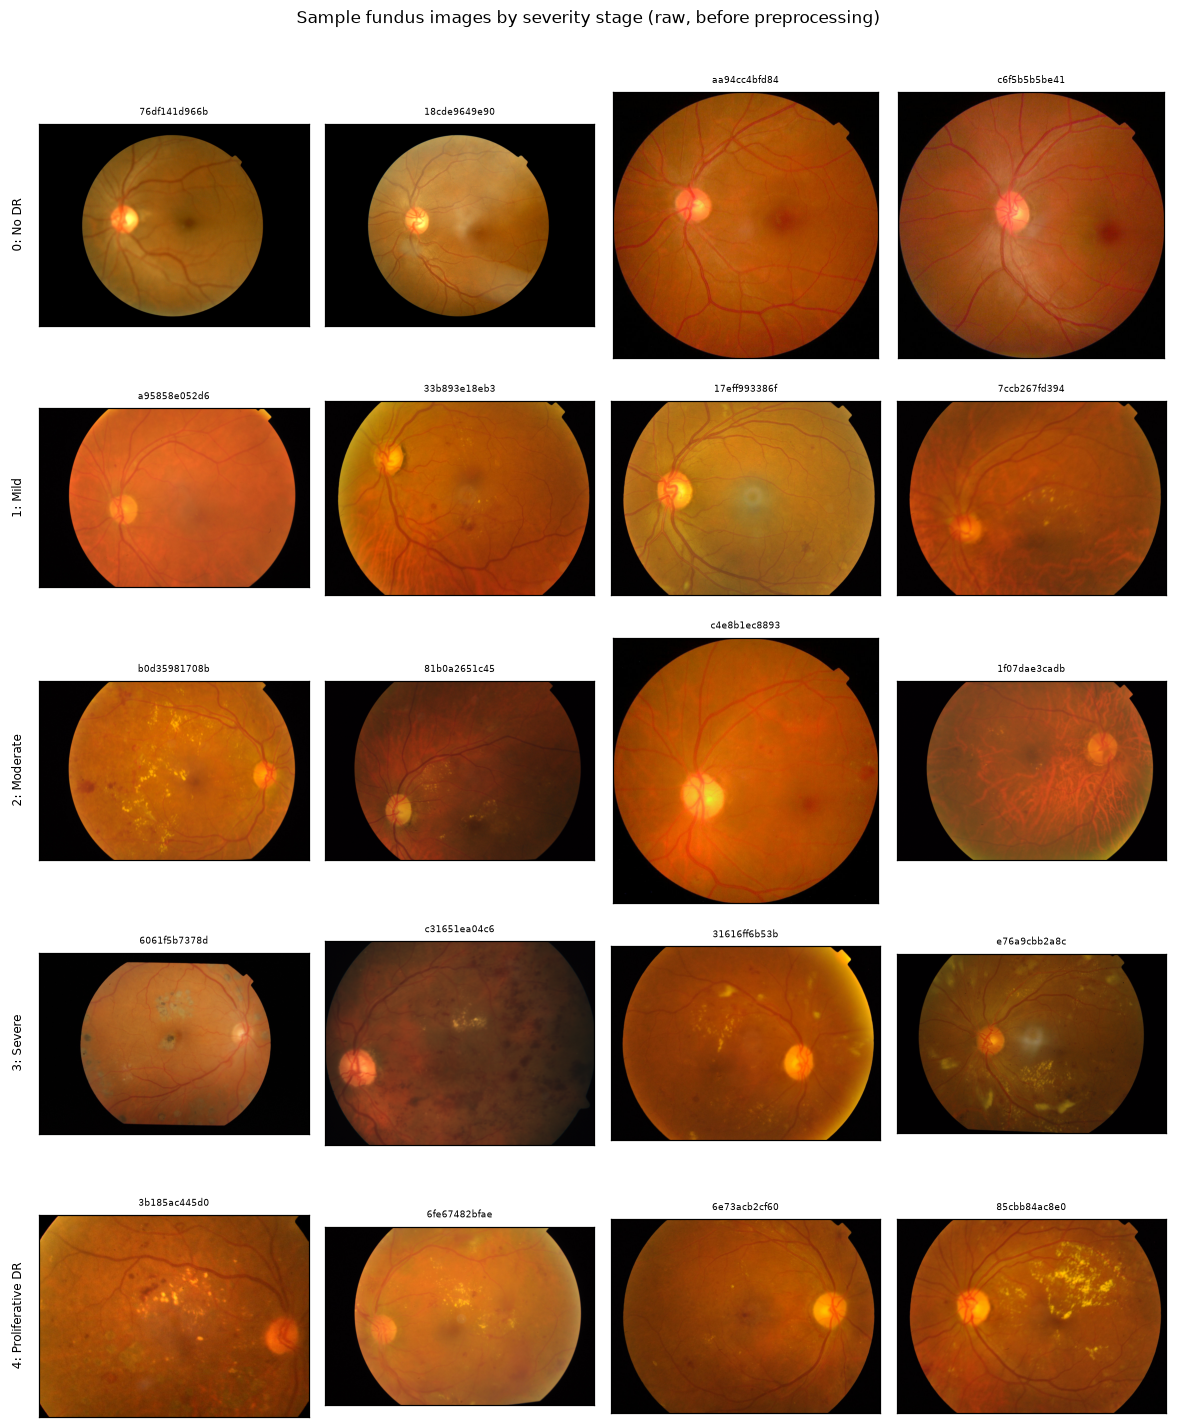

In [11]:
import cv2
from src.data.inspect import pick_samples_per_class

PER_CLASS = 4
samples = pick_samples_per_class(df, ID_COL, LABEL_COL, per_class=PER_CLASS, seed=SEED)

n_classes = len(CLASS_NAMES)
fig, axes = plt.subplots(n_classes, PER_CLASS, figsize=(PER_CLASS * 2.7, n_classes * 2.7))
axes = np.array(axes).reshape(n_classes, PER_CLASS)

for row in range(n_classes):
    subset = samples[samples[LABEL_COL] == row].reset_index(drop=True)
    for col in range(PER_CLASS):
        ax = axes[row, col]
        ax.set_xticks([]); ax.set_yticks([])
        if col >= len(subset):
            ax.axis("off")
            continue
        image_id = subset.loc[col, ID_COL]
        img = cv2.imread(str(IMAGES_DIR / f"{image_id}{IMAGE_EXT}"), cv2.IMREAD_COLOR)
        if img is None:
            ax.set_title("unreadable", fontsize=7)
            continue
        ax.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
        ax.set_title(image_id, fontsize=6)
    axes[row, 0].set_ylabel(f"{row}: {CLASS_NAMES[row]}", fontsize=8, rotation=90, labelpad=10)

fig.suptitle("Sample fundus images by severity stage (raw, before preprocessing)", fontsize=11)
fig.tight_layout(rect=[0, 0, 1, 0.97])

out = FIGURES_DIR / "m1_sample_grid.png"
fig.savefig(out, dpi=150)
print(f"Saved figure -> {out.relative_to(PROJECT_ROOT)}")
plt.show()

## 9. Milestone 1 summary

Everything below is generated from your own data — nothing is hard-coded. Copy it into the
*Dataset* section of your report.

In [12]:
print("=" * 70)
print("  MILESTONE 1 SUMMARY")
print("=" * 70)
print(f"Dataset            : APTOS 2019 Blindness Detection")
print(f"Labelled images    : {len(df)}")
print(f"Classes            : {DS['num_classes']} ({', '.join(CLASS_NAMES)})")
print(f"Duplicate IDs      : {len(duplicates)}")
print(f"Missing image files: {len(missing)}")
print(f"Unreadable images  : {len(unreadable)} (of {len(props)} scanned)")
print(f"Majority class     : {dist.loc[dist['count'].idxmax(), 'class_name']} "
      f"({dist['percent'].max():.1f}%)")
print(f"Minority class     : {dist.loc[dist['count'].idxmin(), 'class_name']} "
      f"({dist['percent'].min():.1f}%)")
print(f"Imbalance ratio    : {dist['count'].max() / dist['count'].min():.1f} : 1")
print(f"Image width  range : {ok['width'].min():.0f} - {ok['width'].max():.0f} px")
print(f"Image height range : {ok['height'].min():.0f} - {ok['height'].max():.0f} px")
print(f"Random seed        : {SEED}")
print("=" * 70)
print("\nArtefacts written:")
for f in sorted(REPORTS_DIR.glob("m1_*.csv")):
    print("  ", f.relative_to(PROJECT_ROOT))
for f in sorted(FIGURES_DIR.glob("m1_*.png")):
    print("  ", f.relative_to(PROJECT_ROOT))

  MILESTONE 1 SUMMARY
Dataset            : APTOS 2019 Blindness Detection
Labelled images    : 3662
Classes            : 5 (No DR, Mild, Moderate, Severe, Proliferative DR)
Duplicate IDs      : 0
Missing image files: 0
Unreadable images  : 0 (of 400 scanned)
Majority class     : No DR (49.3%)
Minority class     : Severe (5.3%)
Imbalance ratio    : 9.4 : 1
Image width  range : 640 - 4288 px
Image height range : 480 - 2848 px
Random seed        : 42

Artefacts written:
   reports\m1_class_distribution.csv
   reports\m1_class_weights.csv
   reports\m1_image_properties.csv
   reports\m1_image_property_summary.csv
   reports\figures\m1_class_distribution.png
   reports\figures\m1_image_size_scatter.png
   reports\figures\m1_sample_grid.png


---

## Milestone 1 complete

**Next:** Milestone 2 — preprocessing and augmentation (`notebooks/02_preprocessing.ipynb`).
There you will implement and visually verify:

- black-border cropping
- resize to 300×300
- ImageNet normalisation
- optional CLAHE contrast enhancement
- the augmentation pipeline (flip, rotate, brightness/contrast, shift-scale)

Before moving on, send your mentor the class distribution table and the imbalance ratio
printed above — those numbers determine the Milestone 5 strategy.